In [3]:
import os
import torch

# Forzar el uso de la GPU 1 (o 2) a nivel de entorno
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Esto hará que la GPU 1 sea vista como la 0 por PyTorch

# Verificar que estamos usando la GPU correcta
print(f"Dispositivos CUDA disponibles: {torch.cuda.device_count()}")
print(f"Dispositivo CUDA actual: {torch.cuda.current_device()}")
print(f"Nombre del dispositivo: {torch.cuda.get_device_name(0)}")

# Establecer opciones de memoria
torch.cuda.set_per_process_memory_fraction(0.7, 0)  # Usar 70% de la memoria de la GPU seleccionada

Dispositivos CUDA disponibles: 3
Dispositivo CUDA actual: 0
Nombre del dispositivo: NVIDIA GeForce GTX 980


In [2]:
#versión con filtros de detección más sensibles


import os
import scanpy as sc
import scvi
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
torch.cuda.set_per_process_memory_fraction(0.5, device=2)

def setup_logger(log_file):
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )

def plot_doublet_scores(df, output_dir, filename):
    plt.figure(figsize=(10, 6))
    plt.hist(df['doublet_score'], bins=50)
    plt.xlabel('Doublet Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Doublet Scores')
    plt.savefig(os.path.join(output_dir, f'{filename}_doublet_scores.png'))
    plt.close()

def remove_doublets(adata, min_counts=3, n_top_genes=7000):
    """
    Mejorada detección de dobletes usando múltiples criterios
    """
    logging.info(f"Initial shape: {adata.shape}")
    
    # 1. Filtrado inicial basado en complejidad
    adata.obs['n_counts'] = adata.X.sum(axis=1)
    adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
    adata.obs['complexity'] = adata.obs['n_genes'] / adata.obs['n_counts']

    # 2. Selección de genes más variables
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_top_genes,
        subset=True,
        flavor='seurat_v3'
    )
    
    # 3. Configuración y entrenamiento de SCVI
    scvi.model.SCVI.setup_anndata(adata)
    vae = scvi.model.SCVI(adata)
    vae.train()
    
    # 4. Configuración y entrenamiento de SOLO con parámetros ajustados
    solo_model = scvi.external.SOLO.from_scvi_model(
        vae
    )
    
    # Entrenamiento con early stopping
    solo_model.train(
        early_stopping=True,
        early_stopping_patience=10
    )
    
    # 5. Predicción y análisis de dobletes
    doublet_scores = solo_model.predict(soft=True)  # Obtener probabilidades
    hard_predictions = solo_model.predict(soft=False)  # Obtener predicciones duras
    
    adata.obs['doublet_score'] = doublet_scores['doublet']
    adata.obs['singlet_score'] = doublet_scores['singlet']
    # Convertir predicciones duras a etiquetas
    adata.obs['doublet_prediction'] = ['doublet' if x else 'singlet' for x in 
                                     (doublet_scores['doublet'] > doublet_scores['singlet'])]
    
    # 6. Criterios múltiples para identificación de dobletes
    is_doublet = (
        (doublet_scores['doublet'] > 0.5) &  # Score de doblete alto
        (doublet_scores['doublet'] - doublet_scores['singlet'] > 0.3) &  # Diferencia significativa
        (adata.obs['complexity'] > np.percentile(adata.obs['complexity'], 95))  # Alta complejidad
    )
    
    # 7. Logging de estadísticas
    n_doublets = is_doublet.sum()
    doublet_rate = (n_doublets / len(adata)) * 100
    
    logging.info(f"Detected {n_doublets} doublets ({doublet_rate:.2f}%)")
    logging.info(f"Mean doublet score: {doublet_scores['doublet'].mean():.3f}")
    logging.info(f"Median doublet score: {np.median(doublet_scores['doublet']):.3f}")
    
    # Añadir más métricas de logging
    logging.info(f"Distribution of predictions:")
    logging.info(adata.obs['doublet_prediction'].value_counts())
    
    # 8. Crear DataFrame con métricas
    doublet_stats = pd.DataFrame({
        'cell_id': adata.obs.index,
        'doublet_score': doublet_scores['doublet'],
        'singlet_score': doublet_scores['singlet'],
        'complexity': adata.obs['complexity'],
        'is_doublet': is_doublet,
        'prediction': adata.obs['doublet_prediction']
    })
    
    # Añadir visualización de la distribución de scores
    plt.figure(figsize=(10, 6))
    plt.hist(doublet_scores['doublet'], bins=50, alpha=0.5, label='Doublet scores')
    plt.hist(doublet_scores['singlet'], bins=50, alpha=0.5, label='Singlet scores')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Doublet/Singlet Scores')
    plt.legend()
    plt.savefig('doublet_scores_distribution.png')
    plt.close()
    
    return adata[~is_doublet], doublet_stats


def process_samples(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    setup_logger(os.path.join(output_dir, 'doublet_removal.log'))
    
    for filename in os.listdir(input_dir):
        if filename.endswith('.h5ad'):
            logging.info(f"\nProcessing {filename}")
            
            # Cargar datos
            adata = sc.read_h5ad(os.path.join(input_dir, filename))
            
            # Remover dobletes
            adata_filtered, doublet_stats = remove_doublets(adata)
            
            # Guardar estadísticas
            stats_file = os.path.join(output_dir, f'{filename}_doublet_stats.csv')
            doublet_stats.to_csv(stats_file)
            
            # Generar visualización
            plot_doublet_scores(doublet_stats, output_dir, filename)
            
            # Guardar datos filtrados
            output_file = os.path.join(output_dir, f'filtered_{filename}')
            adata_filtered.write_h5ad(output_file)
            
            # Logging final
            logging.info(f"Saved filtered data: {adata.n_obs - adata_filtered.n_obs} cells removed")

if __name__ == "__main__":
    input_directory = '/app/project/restore_data/pipeline_articulo/2.quality_control/'
    output_directory = '/app/project/restore_data/pipeline_articulo/3.doublet_removal/'
    process_samples(input_directory, output_directory)

2025-04-05 04:23:15,064 - INFO - 
Processing filtered_NK cells_data.h5ad
2025-04-05 04:23:32,286 - INFO - Initial shape: (339154, 27629)
Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 1/24:   0%|          | 0/24 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 4.12 MiB is free. Process 22374 has 72.75 MiB memory in use. Process 18525 has 3.64 GiB memory in use. Process 16733 has 215.75 MiB memory in use. Of the allocated memory 104.83 MiB is allocated by PyTorch, and 17.17 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
adata= sc.read_h5ad('/app/project/test_data/pipeline_articulo/3.doublet_removal/filtered_filtered_NK cells_data.h5ad')

In [1]:
import scanpy as sc
adata= sc.read_h5ad('/app/project/test_data/pipeline_articulo/3.doublet_removal/filtered_filtered_NK cells_data.h5ad')

Preprocesando datos...
Calculando con n_top_genes = 5000


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


Calculando con n_top_genes = 7500


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


Calculando con n_top_genes = 10000


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


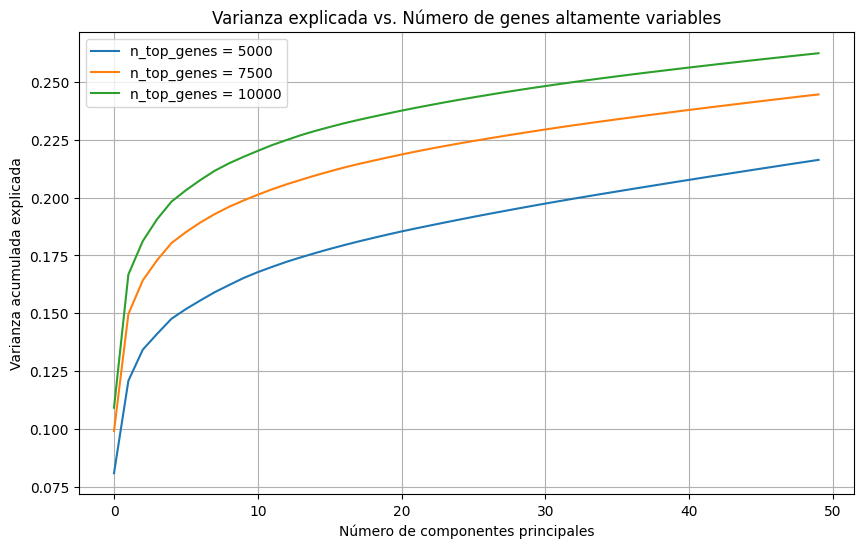


Para n_top_genes = 5000:
Varianza explicada por los primeros 10 PCs: 0.1652
Varianza explicada por los primeros 50 PCs: 0.2163

Para n_top_genes = 7500:
Varianza explicada por los primeros 10 PCs: 0.1987
Varianza explicada por los primeros 50 PCs: 0.2446

Para n_top_genes = 10000:
Varianza explicada por los primeros 10 PCs: 0.2176
Varianza explicada por los primeros 50 PCs: 0.2624


In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Asumiendo que 'adata' ya está cargado

# Preprocesamiento para manejar valores infinitos y muy grandes
print("Preprocesando datos...")
sc.pp.log1p(adata)  # Aplicar transformación logarítmica
adata.X = np.nan_to_num(adata.X, nan=0, posinf=0, neginf=0)  # Reemplazar inf y NaN con 0

# Lista de valores de n_top_genes para probar
n_top_genes_list = [5000, 7500, 10000]

results = {}

for n_top in n_top_genes_list:
    print(f"Calculando con n_top_genes = {n_top}")
    
    # Copia los datos para no modificar el original
    adata_copy = adata.copy()
    
    # Calcula genes altamente variables
    sc.pp.highly_variable_genes(adata_copy, n_top_genes=n_top, flavor='seurat', n_bins=20)
    
    # Filtra para quedarte solo con los genes altamente variables
    adata_copy = adata_copy[:, adata_copy.var.highly_variable]
    
    # Realiza PCA
    sc.tl.pca(adata_copy)
    
    # Calcula la varianza explicada
    variance_ratio = adata_copy.uns['pca']['variance_ratio']
    cumulative_variance_ratio = variance_ratio.cumsum()
    
    # Guarda los resultados
    results[n_top] = cumulative_variance_ratio

# Grafica los resultados
plt.figure(figsize=(10, 6))
for n_top, cumulative_variance in results.items():
    plt.plot(cumulative_variance[:50], label=f'n_top_genes = {n_top}')

plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada vs. Número de genes altamente variables')
plt.legend()
plt.grid(True)
plt.show()

# Imprimir información adicional
for n_top, cumulative_variance in results.items():
    print(f"\nPara n_top_genes = {n_top}:")
    print(f"Varianza explicada por los primeros 10 PCs: {cumulative_variance[9]:.4f}")
    print(f"Varianza explicada por los primeros 50 PCs: {cumulative_variance[49]:.4f}")

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar los datos (asumiendo que ya tienes 'adata' cargado)

# Preprocesamiento para manejar valores infinitos y muy grandes
sc.pp.log1p(adata)  # Aplicar transformación logarítmica
adata.X = np.nan_to_num(adata.X, nan=0, posinf=0, neginf=0)  # Reemplazar inf y NaN con 0

# Calcular genes altamente variables
sc.pp.highly_variable_genes(adata, n_top_genes=10000, flavor='seurat', n_bins=20)

# Crear el gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=adata.var, x='means', y='dispersions_norm', 
                hue='highly_variable', palette={True: 'red', False: 'gray'})
plt.xlabel('Media de expresión (log)')
plt.ylabel('Dispersión normalizada')
plt.title('Genes altamente variables')
plt.legend(title='Altamente variable')

# Ajustar los límites del eje para excluir valores extremos
plt.xlim(adata.var['means'].quantile(0.01), adata.var['means'].quantile(0.99))
plt.ylim(adata.var['dispersions_norm'].quantile(0.01), adata.var['dispersions_norm'].quantile(0.99))

plt.show()

# Imprimir información sobre los genes altamente variables
n_hvg = adata.var['highly_variable'].sum()
print(f"Número de genes altamente variables: {n_hvg}")